In [9]:
import pandas as pd

In [10]:
# load dataset
df = pd.read_csv("Merged_Dataset.csv")

In [11]:
# Separate classes
approved = df[df['CREDIT_CARD_APPROVAL_STATUS'] == 1]
rejected = df[df['CREDIT_CARD_APPROVAL_STATUS'] == 0]

In [12]:
# Check counts
print("Approved:", len(approved))
print("Rejected:", len(rejected))

Approved: 36221
Rejected: 236


In [13]:
# Undersample majority class
approved_sample = approved.sample(n=5100, random_state=42)
rejected_sample = rejected.sample(n=4900, replace=True, random_state=42)

In [14]:
# Combine balanced dataset
balanced_df = pd.concat([approved_sample, rejected_sample])

In [15]:
# Shuffle data
balanced_df = balanced_df.sample(frac=1, random_state=42)

In [16]:
# Save new dataset
balanced_df.to_csv("Balanced_Credit_Card_Dataset.csv", index=False)

In [17]:
print("Balanced dataset created!")
print(balanced_df['CREDIT_CARD_APPROVAL_STATUS'].value_counts())

Balanced dataset created!
CREDIT_CARD_APPROVAL_STATUS
1    5100
0    4900
Name: count, dtype: int64


In [18]:
# columns name
balanced_df.keys()

Index(['index', 'ID', 'GENDER', 'OWN_CAR', 'OWN_REALTY', 'CHILDREN',
       'TOTAL_INCOME', 'INCOME_TYPE', 'EDUCATION_TYPE', 'FAMILY_STATUS',
       'HOUSING_TYPE', 'AGE', 'EXPERIENCE', 'WORK_PHONE', 'OCCUPATION_TYPE',
       'FAM_MEMBERS', 'CREDIT_CARD_APPROVAL_STATUS'],
      dtype='object')

In [19]:
balanced_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 15885 to 36401
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   index                        10000 non-null  int64  
 1   ID                           10000 non-null  int64  
 2   GENDER                       10000 non-null  int64  
 3   OWN_CAR                      10000 non-null  int64  
 4   OWN_REALTY                   10000 non-null  int64  
 5   CHILDREN                     10000 non-null  int64  
 6   TOTAL_INCOME                 10000 non-null  float64
 7   INCOME_TYPE                  10000 non-null  int64  
 8   EDUCATION_TYPE               10000 non-null  int64  
 9   FAMILY_STATUS                10000 non-null  int64  
 10  HOUSING_TYPE                 10000 non-null  int64  
 11  AGE                          10000 non-null  float64
 12  EXPERIENCE                   10000 non-null  float64
 13  WORK_PHONE       

In [20]:
balanced_df.describe()

,index,ID,GENDER,OWN_CAR,OWN_REALTY,CHILDREN,TOTAL_INCOME,INCOME_TYPE,EDUCATION_TYPE,FAMILY_STATUS,HOUSING_TYPE,AGE,EXPERIENCE,WORK_PHONE,OCCUPATION_TYPE,FAM_MEMBERS,CREDIT_CARD_APPROVAL_STATUS
count,10000.00000,1.000000e+04,10000.00000,10000.00000,10000.000000,10000.000000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,128934.75630,5.079489e+06,0.37120,0.37120,0.632900,0.411000,1.893095e+05,2.223400,3.078300,1.458400,1.271000,43.587800,4.969100,0.220000,9.935600,2.165400,0.510000
std,177530.82239,4.189286e+04,0.48315,0.48315,0.482038,0.680827,1.141504e+05,1.776065,1.343559,0.972195,0.910188,11.461746,6.055329,0.414267,4.930384,0.869551,0.499925
min,4.00000,5.008809e+06,0.00000,0.00000,0.000000,0.000000,2.925000e+04,0.000000,0.000000,0.000000,0.000000,20.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,18825.25000,5.045790e+06,0.00000,0.00000,0.000000,0.000000,1.125000e+05,0.000000,1.000000,1.000000,1.000000,34.000000,1.000000,0.000000,6.000000,2.000000,0.000000
50%,36430.50000,5.079166e+06,0.00000,0.00000,1.000000,0.000000,1.575000e+05,2.000000,4.000000,1.000000,1.000000,43.000000,3.000000,0.000000,10.000000,2.000000,1.000000
75%,434463.00000,5.116399e+06,1.00000,1.00000,1.000000,1.000000,2.250000e+05,4.000000,4.000000,2.000000,1.000000,52.000000,7.000000,0.000000,15.000000,3.000000,1.000000
max,434809.00000,5.150481e+06,1.00000,1.00000,1.000000,7.000000,1.575000e+06,4.000000,4.000000,4.000000,5.000000,68.000000,42.000000,1.000000,19.000000,9.000000,1.000000


In [21]:
#no. of unique values in each column
balanced_df.nunique()

index                          5336
ID                             5336
GENDER                            2
OWN_CAR                           2
OWN_REALTY                        2
CHILDREN                          7
TOTAL_INCOME                    172
INCOME_TYPE                       5
EDUCATION_TYPE                    5
FAMILY_STATUS                     5
HOUSING_TYPE                      6
AGE                              48
EXPERIENCE                       43
WORK_PHONE                        2
OCCUPATION_TYPE                  20
FAM_MEMBERS                       8
CREDIT_CARD_APPROVAL_STATUS       2
dtype: int64

In [22]:
# checking null values in each column
balanced_df.isnull().sum()

index                          0
ID                             0
GENDER                         0
OWN_CAR                        0
OWN_REALTY                     0
CHILDREN                       0
TOTAL_INCOME                   0
INCOME_TYPE                    0
EDUCATION_TYPE                 0
FAMILY_STATUS                  0
HOUSING_TYPE                   0
AGE                            0
EXPERIENCE                     0
WORK_PHONE                     0
OCCUPATION_TYPE                0
FAM_MEMBERS                    0
CREDIT_CARD_APPROVAL_STATUS    0
dtype: int64

# Splitting Training and Testing Sets

In [23]:
from sklearn.model_selection import train_test_split

In [24]:
X = balanced_df.drop(['ID', 'CREDIT_CARD_APPROVAL_STATUS'], axis=1)
Y = balanced_df['CREDIT_CARD_APPROVAL_STATUS']

In [25]:
#train-test-split
Xtrain, Xtest, Ytrain, Ytest= train_test_split(X, Y, test_size=0.2, random_state=15)

In [26]:
print("Size of Xtrain Set is:" , len(Xtrain))
print("Size of Xtest Set is:" , len(Xtest))
print("Size of Ytrain Set is:" , len(Ytrain))
print("Size of Ytest Set is:" , len(Ytest))

Size of Xtrain Set is: 8000
Size of Xtest Set is: 2000
Size of Ytrain Set is: 8000
Size of Ytest Set is: 2000


In [27]:
from model import DecisionTreeClassifierCustom, Node

In [28]:
X_train_np = Xtrain.values       # Xtrain is converted into numpy array because it doesnot take a pandas dataframe
y_train_np = Ytrain.values

In [29]:
custom_tree = DecisionTreeClassifierCustom(max_depth=8, min_samples_split=5)
custom_tree.fit(X_train_np, y_train_np)

  Building tree... 100 nodes created
  Total nodes created: 171


In [30]:
X_test_np = Xtest.values
y_pred = custom_tree.predict(X_test_np)

In [31]:
y_pred

array([1, 0, 0, ..., 0, 0, 1], shape=(2000,))

In [32]:
accuracy = (y_pred == Ytest.values).mean()
print("Accuracy:", accuracy)

Accuracy: 0.876


In [33]:
accuracy = (y_pred == Ytest.values).mean() * 100        # in percentage
print("Accuracy:", accuracy)

Accuracy: 87.6


In [34]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Ytest, y_pred)
cm

array([[850, 136],
       [112, 902]])

In [35]:
import matplotlib.pyplot as plt

In [36]:
import seaborn as sns

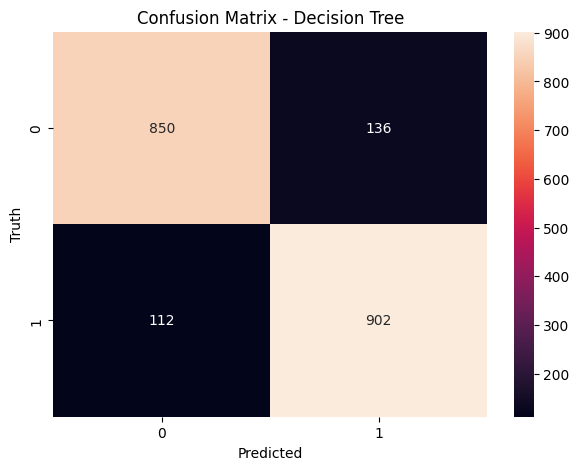

In [37]:
from sklearn.metrics import confusion_matrix

# Predict using trained model
y_pred = custom_tree.predict(Xtest.values)

# Create confusion matrix
cm = confusion_matrix(Ytest, y_pred)

# Plot heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='g', cmap='rocket')

plt.xlabel("Predicted")
plt.ylabel("Truth")
plt.title("Confusion Matrix - Decision Tree")

plt.show()

In [39]:
# Define confusion matrix values
TP = 902
FP = 136
TN = 850
FN = 112

In [45]:
# precision
precision = TP / (TP + FP)
print(f"Precision: {precision*100:.2f}%")


Precision: 86.90%


In [46]:
# recall
recall = TP / (TP + FN)
print(f"Recall: {recall*100:.2f}%")


Recall: 88.95%


In [ ]:
# f1- score
f1_score = 2 * (precision * recall) / (precision + recall)
print(f"F1-Score: {f1_score*100:.2f}%")


F1-Score: 0.8791 (87.91%)


In [49]:
import joblib

In [50]:
# save
joblib.dump(custom_tree, 'custom_decision_tree.pkl')

['custom_decision_tree.pkl']

In [51]:
# load
dtree=joblib.load('custom_decision_tree.pkl')

In [52]:
balanced_df

,index,ID,GENDER,OWN_CAR,OWN_REALTY,CHILDREN,TOTAL_INCOME,INCOME_TYPE,EDUCATION_TYPE,FAMILY_STATUS,HOUSING_TYPE,AGE,EXPERIENCE,WORK_PHONE,OCCUPATION_TYPE,FAM_MEMBERS,CREDIT_CARD_APPROVAL_STATUS
36251,434607,5061691,0,0,1,1,67500.0,0,1,1,1,24.0,4.0,0,19,3.0,0
7912,12002,5036707,1,1,1,0,180000.0,4,4,1,1,46.0,4.0,0,8,2.0,1
3220,3480,5022848,1,0,1,0,180000.0,0,4,2,1,34.0,2.0,0,8,1.0,1
34421,47741,5145914,1,1,1,1,180000.0,0,1,1,1,41.0,4.0,0,12,3.0,1
5026,6429,5025171,1,1,1,1,171000.0,4,4,1,1,27.0,2.0,0,10,3.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31722,44757,5135344,1,0,1,0,112500.0,0,1,1,1,55.0,1.0,0,18,2.0,0
36176,434532,5036469,1,1,0,0,112500.0,2,4,3,1,55.0,4.0,0,4,2.0,0
9313,14467,5041522,1,1,1,0,450000.0,0,1,2,1,44.0,2.0,1,12,1.0,0
18704,24683,5069499,0,1,1,0,157500.0,0,4,1,1,39.0,5.0,0,16,2.0,1


In [ ]:
# handling missing data
appdf = appdf.dropna()

# removing duplicates
appdf = appdf.drop_duplicates()

